In [2]:
# Import libraries
import pandas as pd  # for handling dataset (tables)
import numpy as np   # for numerical operations

from sklearn.preprocessing import StandardScaler  # for scaling numeric features
from sklearn.model_selection import train_test_split  # for splitting data
from sklearn.feature_extraction.text import TfidfVectorizer  # convert text → numbers

from scipy.sparse import hstack  # combine sparse + dense features


# Load dataset
df = pd.read_csv('../data/fake_job_postings.csv')  # read CSV file into dataframe

print(df.shape)  # print number of rows and columns
df.head()  # show first 5 rows


# Remove duplicates
df = df.drop_duplicates()  # removes repeated rows


# Fill missing text values
text_cols = ['description', 'company_profile', 'requirements']  # text columns list
for col in text_cols:
    df[col] = df[col].fillna("")  # replace NaN with empty string


# Fill missing categorical values
df['location'] = df['location'].fillna("Unknown")  # replace missing location


# Ensure target is integer
df['fraudulent'] = df['fraudulent'].astype(int)  # convert target to 0/1


# -------- Feature Engineering --------

df['desc_length'] = df['description'].apply(len)  # length of description text
df['company_profile_length'] = df['company_profile'].apply(len)  # company profile length
df['req_length'] = df['requirements'].apply(len)  # requirements length

df['has_salary'] = df['salary_range'].notnull().astype(int)  # 1 if salary exists else 0
df['has_company_profile'] = (df['company_profile'] != "").astype(int)  # 1 if profile exists


# -------- TF-IDF (Text Features) --------

tfidf = TfidfVectorizer(max_features=2000, stop_words='english')  # keep top 2000 words

text_data = df['description'] + " " + df['requirements']  # combine text columns
X_text = tfidf.fit_transform(text_data)  # convert text → numeric matrix


# -------- Numeric Features --------

num_features = df[['desc_length', 'company_profile_length', 'req_length',
                   'has_salary', 'has_company_profile']]  # select numeric columns

scaler = StandardScaler()  # create scaler object
X_num = scaler.fit_transform(num_features)  # scale numeric values


# -------- Combine Features --------

X = hstack([X_text, X_num])  # combine text + numeric features
y = df['fraudulent']  # target variable


# -------- Train-Test Split --------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # 80-20 split with balance
)

print("Training shape:", X_train.shape)  # check training data shape

(17880, 18)
Training shape: (14304, 2005)


In [3]:
# Import models and metrics
from sklearn.linear_model import LogisticRegression  # logistic regression model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score  # evaluation metrics


# -------- Evaluation Function --------

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)  # predict labels for test data
    
    return {
        "Model": name,  # model name
        "Accuracy": accuracy_score(y_test, y_pred),  # overall correctness
        "Precision": precision_score(y_test, y_pred),  # correct positive predictions
        "Recall": recall_score(y_test, y_pred),  # how many actual positives found
        "F1": f1_score(y_test, y_pred)  # balance of precision + recall
    }


# -------- Logistic Regression --------

lr = LogisticRegression(max_iter=1000)  # create model (increase iterations for convergence)
lr.fit(X_train, y_train)  # train model

result_lr = evaluate_model("Logistic", lr, X_test, y_test)  # evaluate model


# -------- L1 Regularization --------

lr_l1 = LogisticRegression(penalty='l1', solver='liblinear', C=1.0)  # L1 removes features
lr_l1.fit(X_train, y_train)  # train model

result_l1 = evaluate_model("L1 Regularized", lr_l1, X_test, y_test)  # evaluate


# -------- L2 Regularization --------

lr_l2 = LogisticRegression(penalty='l2', max_iter=1000, C=1.0)  # L2 reduces overfitting
lr_l2.fit(X_train, y_train)  # train model

result_l2 = evaluate_model("L2 Regularized", lr_l2, X_test, y_test)  # evaluate


# -------- Compare Results --------

import pandas as pd  # import pandas for table

results_df = pd.DataFrame([result_lr, result_l1, result_l2])  # create comparison table
results_df  # display results

c:\Users\sivanand\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\sivanand\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\sivanand\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of

,Model,Accuracy,Precision,Recall,F1
0,Logistic,0.966723,0.965517,0.323699,0.484848
1,L1 Regularized,0.968400,0.884615,0.398844,0.549801
2,L2 Regularized,0.966723,0.965517,0.323699,0.484848


c:\Users\sivanand\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9570 - loss: 0.1489 - val_accuracy: 0.9720 - val_loss: 0.0876
Epoch 2/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9785 - loss: 0.0646 - val_accuracy: 0.9755 - val_loss: 0.0747
Epoch 3/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9910 - loss: 0.0302 - val_accuracy: 0.9790 - val_loss: 0.0691
Epoch 4/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9974 - loss: 0.0122 - val_accuracy: 0.9769 - val_loss: 0.0792
Epoch 5/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9991 - loss: 0.0044 - val_accuracy: 0.9804 - val_loss: 0.0896
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3403
           1       0.85      0.75      0.80       173

    accuracy                           0.98      3576
   macro avg       0.92      0.87      0.89      3576
weighted avg       0.98      0.98      0.98      357

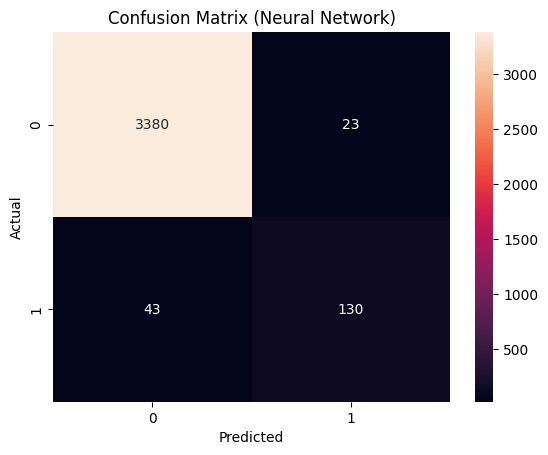

,Model,Accuracy,Precision,Recall,F1
0,Logistic,0.966723,0.965517,0.323699,0.484848
1,L1 Regularized,0.968400,0.884615,0.398844,0.549801
2,L2 Regularized,0.966723,0.965517,0.323699,0.484848
3,Neural Network,0.981544,0.849673,0.751445,0.797546


In [4]:
# Import deep learning libraries
from tensorflow.keras.models import Sequential  # sequential model
from tensorflow.keras.layers import Dense  # dense layers


# -------- Convert Sparse to Dense --------

X_train_nn = X_train.toarray()  # convert sparse → dense for NN
X_test_nn = X_test.toarray()  # convert test data


# -------- Build Neural Network --------

model = Sequential()  # initialize model

model.add(Dense(64, activation='relu', input_dim=X_train_nn.shape[1]))  # first hidden layer
model.add(Dense(32, activation='relu'))  # second hidden layer
model.add(Dense(1, activation='sigmoid'))  # output layer (binary classification)


# -------- Compile Model --------

model.compile(
    optimizer='adam',  # optimization algorithm
    loss='binary_crossentropy',  # loss for binary classification
    metrics=['accuracy']  # track accuracy
)


# -------- Train Model --------

history = model.fit(
    X_train_nn, y_train,  # training data
    epochs=5,  # number of iterations
    batch_size=32,  # data per batch
    validation_split=0.1  # validation data
)


# -------- Predictions --------

y_pred_nn = (model.predict(X_test_nn) > 0.5).astype(int)  # convert probability → 0/1


# -------- Evaluation --------

from sklearn.metrics import classification_report  # detailed metrics

print(classification_report(y_test, y_pred_nn))  # print precision, recall, F1


# -------- Confusion Matrix --------

import seaborn as sns  # visualization
import matplotlib.pyplot as plt  # plotting
from sklearn.metrics import confusion_matrix  # confusion matrix

cm = confusion_matrix(y_test, y_pred_nn)  # compute matrix

sns.heatmap(cm, annot=True, fmt='d')  # plot heatmap
plt.title("Confusion Matrix (Neural Network)")  # title
plt.xlabel("Predicted")  # x-axis
plt.ylabel("Actual")  # y-axis
plt.show()  # display plot


# -------- Add NN Results to Table --------

result_nn = {
    "Model": "Neural Network",
    "Accuracy": accuracy_score(y_test, y_pred_nn),
    "Precision": precision_score(y_test, y_pred_nn),
    "Recall": recall_score(y_test, y_pred_nn),
    "F1": f1_score(y_test, y_pred_nn)
}

results_df = pd.concat([results_df, pd.DataFrame([result_nn])], ignore_index=True)  # add to table
results_df  # final comparison